In [38]:
pip install langchain langgraph pydantic langchain-groq python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [39]:
pip install -qU langchain-groq

Note: you may need to restart the kernel to use updated packages.


In [40]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [ ]:
import os



In [43]:
class BatsManState(TypedDict):
    runs: int
    six: int
    four: int
    balls: int

    sr: float
    bpb: float
    boundary_percentage: float
    summry: str

In [44]:
def calculate_sr(state: BatsManState):
    sr= (state['runs']/state['balls'])*100
    return {'sr':sr }

In [45]:
def calculate_bpb(state: BatsManState):
    bpb=state['balls']/(state['four']+state['six'])
    return {'bpb':bpb}
    

In [46]:
def calculate_boundary_percentage(state: BatsManState):
    boundary_percentage= (((state['four']*4) + (state['six']*6)) / state['runs'])*100
    return {'boundary_percentage': boundary_percentage}

In [47]:
def summry(state: BatsManState):
    summry=f"""
    Strike rate - {state['sr']}\n
    balles per boundry - {state['bpb']} \n
    boundary percent - {state['boundary_percentage']}
    """
    print
    return {'summry': summry}

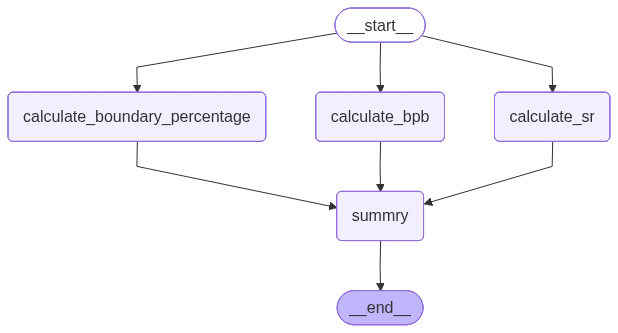

In [48]:
graph=StateGraph(BatsManState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('summry', summry)

#adding edges

graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundary_percentage')

graph.add_edge('calculate_sr', 'summry')
graph.add_edge('calculate_bpb', 'summry')
graph.add_edge('calculate_boundary_percentage', 'summry')

graph.add_edge('summry',END)

workflow= graph.compile()

workflow

In [56]:
intial_state= {
    'runs': 50,
    'six': 4,
    'four': 3,
    'balls': 12
}
workflow.invoke(intial_state)

{'runs': 50,
 'six': 4,
 'four': 3,
 'balls': 12,
 'sr': 416.6666666666667,
 'bpb': 1.7142857142857142,
 'boundary_percentage': 72.0,
 'summry': '\n    Strike rate - 416.6666666666667\n\n    balles per boundry - 1.7142857142857142 \n\n    boundary percent - 72.0\n    '}